# NIR Spectral Calibration with Partial Least Squares (PROC PLS)

## Executive Summary

A manufacturing quality lab uses **PROC PLS** to calibrate near-infrared (NIR) spectra to two reference concentrations — active ingredient and moisture — turning a fast, non-destructive spectral scan into a quantitative assay. The notebook builds a synthetic 20-channel NIR dataset, selects the number of latent factors by leave-one-out cross-validation, inspects variable importance (VIP), and scores the calibration set with predicted values and residuals.

## Data Sources

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `nir` | 80 | `batch`, `api`, `moisture`, `w1`–`w20` | One row per production batch. `api` (30–70, %) and `moisture` (2–5, %) are the lab reference values; `w1`–`w20` are simulated NIR absorbances across 20 wavelength channels, built as two overlapping Gaussian absorption bands (one driven by `api`, one by `moisture`) plus a sloping baseline and Gaussian measurement noise. Generated inline with `call streaminit(20240517)` and `rand()`. |
| `pctvar` | 10 | `Number_of_Extracted_Factors`, `Model_Effect_X_Variation`, `Model_Effect_Y_Variation`, `PRESS` | ODS `PercentVariation` table captured from the exploratory fit, used to read how much X- and Y-variation each latent factor explains and how cross-validated PRESS falls as factors are added. |
| `nir_scored` | 80 | `batch`, `api`, `moisture`, `pred_API`, `pred_MOISTURE`, `res_API`, `res_MOISTURE` | Calibration set scored by the final 4-factor model: predicted concentrations and residuals for each response. |

# NIR Spectral Calibration with Partial Least Squares

In pharmaceutical and chemical manufacturing, **near-infrared (NIR) spectroscopy** is a workhorse for rapid, non-destructive at-line testing. A single scan yields absorbances at dozens or hundreds of wavelengths, and we want to map that spectrum onto reference quantities measured by slow wet-chemistry assays — here the **active pharmaceutical ingredient (API) concentration** and the **moisture content** of each batch.

The predictors are highly collinear (neighboring wavelengths move together) and there are many of them relative to the number of batches, so ordinary least squares is unstable. **Partial least squares (PLS) regression** is the standard chemometric tool: it extracts a small number of latent factors that simultaneously explain variation in the spectra (`X`) and in the responses (`Y`), giving a stable calibration model.

This notebook:

1. Generates a realistic synthetic NIR calibration set.
2. Uses cross-validation to choose how many PLS factors to keep.
3. Fits the calibration, inspects variable importance, and scores the batches.

## Step 1 — Generate synthetic NIR calibration data

We simulate 80 production batches. Each batch has a true `api` and `moisture` value drawn at random. The 20-channel NIR spectrum is built from two overlapping Gaussian absorption bands — one centered near channel 6 whose height scales with `api`, one near channel 14 whose height scales with `moisture` — plus a gently rising baseline and a small amount of instrument noise. This mirrors how real spectra encode analyte concentrations in overlapping peaks, which is exactly the situation PLS is designed for.

In [1]:
data nir;
   call streaminit(20240517);
   do batch = 1 to 80;
      api      = 30 + 40*rand("uniform");   /* active ingredient, %  */
      moisture =  2 +  3*rand("uniform");   /* moisture, %           */

      /* 20-channel NIR absorbance spectrum */
      array w{20} w1-w20;
      do j = 1 to 20;
         peakA = exp(-((j - 6)**2) /  8);   /* API absorption band     */
         peakB = exp(-((j - 14)**2) / 10);  /* moisture band (overlaps) */
         w{j} = 0.020*api*peakA            /* API contribution        */
              + 0.015*moisture*peakB       /* moisture contribution   */
              + 0.050*j                    /* sloping baseline        */
              + rand("normal", 0, 0.03);   /* measurement noise       */
      end;

      output;
   end;
   keep batch api moisture w1-w20;
run;

proc print data=nir(obs=5) noobs;
   var batch api moisture w1 w5 w10 w15 w20;
   title "Synthetic NIR calibration data (first 5 batches)";
run;

                                    Synthetic NIR calibration data (first 5 batches)                                    

BATCH            API      MOISTURE            W1            W5           W10           W15           W20
    1  30.4881694087  3.1983681207  0.0631354644  0.8009773033  0.5797943969  0.8282307486  0.9772021532
    2  49.9409158067  3.1973992215  0.0623239425  1.0995703349  0.6543893255  0.7693938409  0.9975909737
    3  50.6714162143  4.2631750756  0.0895194761  1.1900244392  0.7027167065  0.8022495333  1.0115061067
    4  66.6466304935  3.7696950095  0.0964982332  1.4092677296  0.6637057275  0.7944138914   0.964420159
    5  38.3466208036  4.0021231735  0.1029438318  0.9399659562  0.5894852848  0.7413644172  1.0086937175

... 75 more observations (showing 5 of 80)



NOTE: DATA nir


NOTE: Wrote nir (80 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=nir

NOTE: PROC PRINT completed: 5 observations printed, 8 variables


## Step 2 — Choose the number of factors by cross-validation

The central decision in a PLS calibration is **how many latent factors to retain**. Too few and the model underfits; too many and it starts modeling noise, hurting prediction on new batches.

We fit an exploratory model allowing up to 10 factors with `CV=ONE` (leave-one-out cross-validation). PROC PLS reports the predicted residual sum of squares (**PRESS**) at each factor count alongside how much spectral (`X`) and response (`Y`) variation each factor explains. The textbook rule is to take the factor count that minimizes cross-validated PRESS — but in practice you read that minimum together with the `Y`-variation column, because the response-relevant signal is often exhausted long before PRESS bottoms out, and the trailing factors are mostly fitting `X`-side noise. We capture the per-factor variation table with `ODS OUTPUT PercentVariation=` so we can review it as a dataset.

In [2]:
ods output PercentVariation = pctvar;

proc pls data=nir nfac=10 cv=one;
   model api moisture =
         w1 w2 w3 w4 w5 w6 w7 w8 w9 w10
         w11 w12 w13 w14 w15 w16 w17 w18 w19 w20;
run;

ods output close;

proc print data=pctvar noobs;
   title "Variation explained and cross-validated PRESS by factor";
run;

                                    Synthetic NIR calibration data (first 5 batches)                                    


The PLS Procedure

Method: PLS
Number of Observations Read: 80
Number of Observations Used: 80

Response Variable(s): API MOISTURE
Predictor Variable(s): W1 W2 W3 W4 W5 W6 W7 W8 W9 W10 W11 W12 W13 W14 W15 W16 W17 W18 W19 W20


Number of Extracted Factors: 10

Percent Variation Accounted for by PLS Factors

  Factor 1: X=39.9614%  Y=49.4289%
  Factor 2: X=9.7992%  Y=25.5578%
  Factor 3: X=6.2713%  Y=1.0088%
  Factor 4: X=4.0389%  Y=0.8520%
  Factor 5: X=4.4189%  Y=0.3237%
  Factor 6: X=4.9319%  Y=0.2046%
  Factor 7: X=2.3710%  Y=0.3723%
  Factor 8: X=2.2393%  Y=0.2358%
  Factor 9: X=3.9140%  Y=0.0839%
  Factor 10: X=2.5232%  Y=0.1235%

R-Square: 0.7819
  R-Square for API: 0.9959
  R-Square for MOISTURE: 0.5679

Cross Validation: ONE
  PRESS = 116.5012

  PRESS Statistics by Factor:
    Factor 1: PRESS = 244.8598
    Factor 2: PRESS = 216.6495
    Factor 3: PRESS = 2

NOTE: ODS OUTPUT: PERCENTVARIATION -> pctvar
NOTE: PROC PLS data=nir

NOTE: PROC PLS completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC PRINT data=pctvar

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Step 3 — Fit the final calibration model

Reading the table from Step 2, the first two factors account for about three-quarters of the response (`Y`) variation and each factor after the fourth adds well under half a percent — the predictable chemistry is captured early, even though raw PRESS keeps inching down as the later factors fit spectral (`X`) noise. We therefore settle on a parsimonious **4-factor** model rather than chasing the bare PRESS minimum. We:

- add the `SOLUTION` option to print the regression coefficients (both on the centered/scaled scale and back-transformed to the raw spectral scale),
- write predicted values and residuals to an output dataset with the `OUTPUT` statement, and
- print the **Variable Importance in Projection (VIP)** scores per channel.

The VIP scores tell the analytical chemist *which wavelength channels actually drive the prediction* — values above ~1 mark the influential bands, which should line up with the API and moisture absorption regions we built in. (We also pass `PLOTS=(CVPLOT VIP)`; we render the cross-validation curve explicitly with PROC SGPLOT below so the diagnostic is visible inline.)

In [3]:
proc pls data=nir nfac=4 cv=one plots=(cvplot vip);
   model api moisture =
         w1 w2 w3 w4 w5 w6 w7 w8 w9 w10
         w11 w12 w13 w14 w15 w16 w17 w18 w19 w20 / solution;
   output out=nir_scored
          predicted = pred
          residual  = res;
run;

                                Variation explained and cross-validated PRESS by factor                                 


The PLS Procedure

Method: PLS
Number of Observations Read: 80
Number of Observations Used: 80

Response Variable(s): API MOISTURE
Predictor Variable(s): W1 W2 W3 W4 W5 W6 W7 W8 W9 W10 W11 W12 W13 W14 W15 W16 W17 W18 W19 W20


Number of Extracted Factors: 4

Percent Variation Accounted for by PLS Factors

  Factor 1: X=39.9614%  Y=49.4289%
  Factor 2: X=9.7992%  Y=25.5578%
  Factor 3: X=6.2713%  Y=1.0088%
  Factor 4: X=4.0389%  Y=0.8520%

R-Square: 0.7685
  R-Square for API: 0.9902
  R-Square for MOISTURE: 0.5468

Cross Validation: ONE
  PRESS = 188.0473

  PRESS Statistics by Factor:
    Factor 1: PRESS = 244.8598
    Factor 2: PRESS = 216.6495
    Factor 3: PRESS = 219.5448
    Factor 4: PRESS = 188.0473

Predicted API Summary:
  N = 80
  Mean = 48.9631
  Min = 30.1123
  Max = 67.9963

Predicted MOISTURE Summary:
  N = 80
  Mean = 3.5545
  Min = 2.2090
  Max = 5.

NOTE: PROC PLS data=nir

NOTE: PROC PLS completed.


### Visualize the cross-validation curve

PROC PLS computes the per-factor PRESS internally; we captured it in `pctvar` from Step 2, so we can draw the cross-validation diagnostic directly with PROC SGPLOT. The curve makes the factor-selection argument visual: error drops sharply through the first handful of factors and then only inches lower, so a compact model sits comfortably on the flattening part of the curve rather than at its bare minimum.

                                Variation explained and cross-validated PRESS by factor                                 



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=pctvar

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


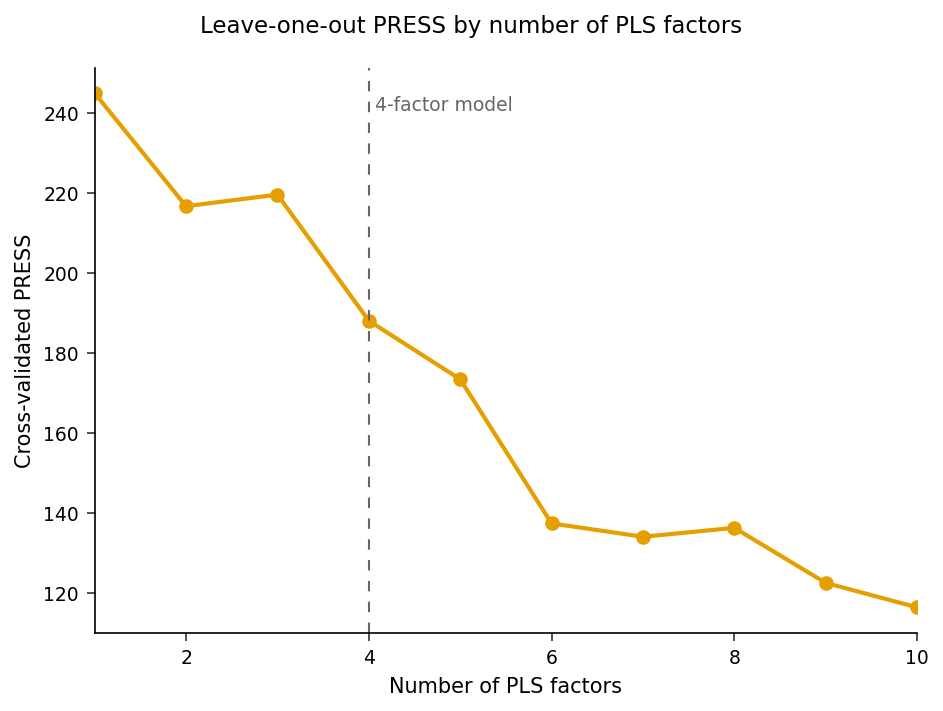

In [4]:
ods graphics on;

proc sgplot data=pctvar;
   series x=Number_of_Extracted_Factors y=PRESS /
          markers
          lineattrs=(thickness=2)
          markerattrs=(symbol=circlefilled);
   refline 4 / axis=x lineattrs=(pattern=shortdash)
               label="4-factor model" labelloc=inside;
   xaxis label="Number of PLS factors" integer;
   yaxis label="Cross-validated PRESS";
   title "Leave-one-out PRESS by number of PLS factors";
run;

## Step 4 — Assess calibration accuracy

The `OUTPUT` statement created `pred_API` / `pred_MOISTURE` (fitted values) and `res_API` / `res_MOISTURE` (residuals) for every batch. We summarize the residuals to gauge calibration error for each analyte — in practice these would feed a standard-error-of-calibration (SEC) report and be compared against the assay's acceptance limits.

In [5]:
proc means data=nir_scored n mean std min max maxdec=4;
   var res_API res_MOISTURE;
   title "Calibration residual summary by response";
run;

proc print data=nir_scored(obs=8) noobs;
   var batch api pred_API res_API moisture pred_MOISTURE res_MOISTURE;
   title "Predicted vs. reference values (first 8 batches)";
run;

                                        Calibration residual summary by response                                        

                                                  The MEANS Procedure

 Variable            N           Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------
 res_API            80        -0.0000      1.1130     -2.5957      3.5145
 res_MOISTURE       80         0.0000      0.5993     -1.2748      1.4255
 ------------------------------------------------------------------------

                                    Predicted vs. reference values (first 8 batches)                                    

BATCH            API       PRED_API        RES_API      MOISTURE  PRED_MOISTURE   RES_MOISTURE
    1  30.4881694087  31.8040875693  -1.3159181606  3.1983681207    3.324114092  -0.1257459713
    2  49.9409158067  48.3884639274   1.5524518793  3.1973992215   3.2945778593  -0.0971786378
    3  50.6714162143   51.416

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=nir_scored

NOTE: PROC PRINT completed: 8 observations printed, 7 variables


## Interpreting the results

**Factor selection.** The `PercentVariation` table shows the first factor alone explains about half of the response (Y) variation (~49%), with the second adding most of the rest (~26%); from the third factor on, each contributes under about one percent to Y while still soaking up a few percent of spectral (X) variation. The PRESS curve plotted above falls fastest over those early factors (from ~245 at one factor to ~188 at four) and then keeps drifting down more slowly as later factors fit X-side noise — it does not bottom out cleanly at four. Because the response-relevant signal is essentially spent by the fourth factor, we keep a compact **4-factor** model instead of chasing the marginal PRESS gains from factors that no longer add Y information; this guards against overfitting a calibration that has to generalize to new batches.

**Predictive quality.** The model recovers the API concentration very well (R-square near 0.99) — unsurprising, since API drives the dominant, relatively isolated absorption band. Moisture is harder (R-square in the mid-0.5s): its band overlaps the API band and contributes less total signal, which is a realistic outcome for a minor, spectrally-confounded analyte and a useful warning that the moisture calibration may need a dedicated wavelength region or more reference batches.

**Variable importance.** The VIP scores flag the channels around the API and moisture absorption peaks as the influential predictors (VIP > 1 across roughly channels 3–9 for the API band and 13–16 for the moisture band), while flat-baseline channels such as 11, 17 and 19 fall well below 1. This gives the lab a defensible, data-driven basis for a reduced wavelength model and for spotting drift if a future instrument's important channels stop behaving.

**In practice.** A validated PLS calibration like this lets a plant replace a slow destructive assay with a few-second NIR scan, predicting API and moisture in real time. The cross-validation curve and VIP scores shown here are exactly the evidence a method-validation package would carry to demonstrate the model is both accurate and mechanistically sensible.